# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [7]:
# 1. How big is the data ?
df.shape

(7043, 21)

In [8]:
df.size

147903

In [3]:
# 2. How does the data look like?
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
837,6982-SSHFK,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,44.40,44.4,Yes
2999,1038-RQOST,Male,0,Yes,Yes,19,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.60,414.95,No
4144,7181-OQCUT,Male,0,No,No,21,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,No,Mailed check,103.85,2215,No
4018,2969-WGHQO,Female,0,Yes,Yes,7,Yes,No,DSL,Yes,...,Yes,No,Yes,No,One year,No,Electronic check,69.45,477.05,No
2507,9668-PUGNU,Male,0,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,24.50,1816.2,No


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 3. What is the data type of each columns?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# 4. Are there any missing values?
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# 5. How does the data look mathematically?
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
# 6. Are there duplicate values?
df.duplicated().sum()

np.int64(0)

In [15]:
# 7. How is the correlation between the columns?
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


## Datatype Fixing 

In [8]:
df["TotalCharges"].dtype

dtype('O')

Since, TotalCharges is an object datatype, we need to change it to numeric for calculation.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df["TotalCharges"].dtype

dtype('float64')

In [18]:
# Pandas profiling of the dataset
from data_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='telecom_churn.html')

Export report to file: 100%|████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 115.69it/s]


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): 
- y (target variable): 
- Probability distribution of y: 
- Natural loss function: 
- Hypothesis class: 
- Assumption 1: 
- Assumption 2: 
- Assumption 3: 
- Sources of uncertainty: 

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


## Handling missing values

In [38]:
# There are some rows in the dataset that contain missing values of TotalCharges.
df["TotalCharges"].isnull().sum()

np.int64(0)

In [39]:
df.shape

(7043, 21)

In [40]:
# Since, only 11 rows have missing values for TotalCharges, we can safely drop them.
# df = df.dropna(subset=['TotalCharges'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.shape

(7043, 21)

### Skewness Interpretation

- 0 ≈ symmetric distribution  
- \> 0 → right-skewed (long tail to the right)  
- < 0 → left-skewed (long tail to the left)  

---

### Rule of Thumb

| Skewness (absolute value) | Interpretation              |
|--------------------------|----------------------------|
| < 0.5                    | Approximately symmetric     |
| 0.5 – 1.0                | Moderately skewed          |
| > 1.0                    | Highly skewed              |

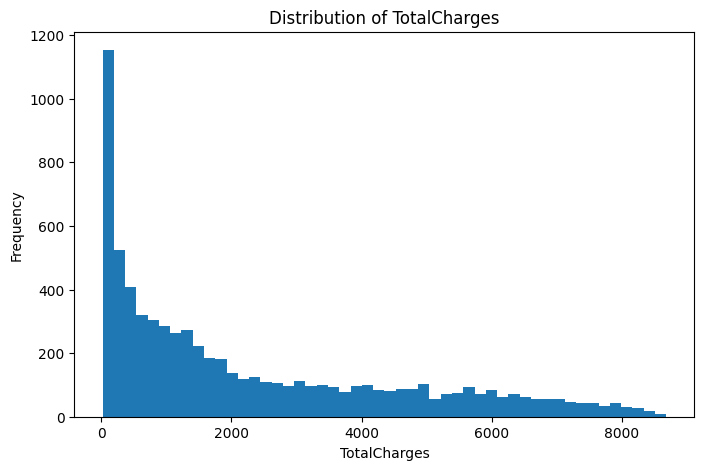

In [23]:
# Distribution of TotalCharges

plt.figure(figsize=(8,5))
plt.hist(df['TotalCharges'], bins=50)
plt.title('Distribution of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.show()

In [25]:
df['TotalCharges'].skew()

np.float64(0.9616424997242504)

The column 'TotalCharges' is heavily right skewed

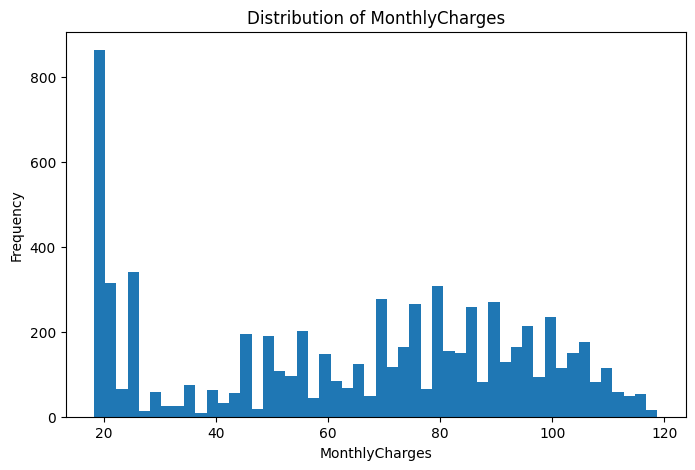

In [22]:
# Distribution of MonthlyCharges

plt.figure(figsize=(8,5))
plt.hist(df['MonthlyCharges'], bins=50)
plt.title('Distribution of MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.show()

In [26]:
df['MonthlyCharges'].skew()

np.float64(-0.22210292770166232)

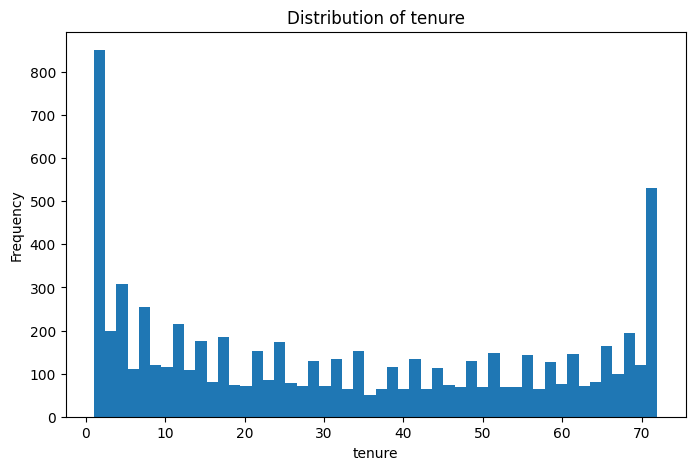

In [24]:
# Distribution of tenure

plt.figure(figsize=(8,5))
plt.hist(df['tenure'], bins=50)
plt.title('Distribution of tenure')
plt.xlabel('tenure')
plt.ylabel('Frequency')
plt.show()

In [27]:
df['tenure'].skew()

np.float64(0.23773083190513133)

## Encoding of Churn column

In [12]:
df["Churn"].dtype

dtype('O')

Since, datatype of Churn is an object, we need to change it to boolean (integer: 0 & 1) for modeling.

In [13]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
df["Churn"].dtype

dtype('int64')

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [30]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 645.7 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.1 MB 645.7 kB/s eta 0:00:12
   --- ---------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [32]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report
)

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


# Data Cleaning


# Replace whitespace with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Drop missing TotalCharges rows
df = df.dropna(subset=['TotalCharges'])

# Convert target column into numeric
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

# Remove customerID because it is not useful for prediction
df = df.drop(columns=['customerID'])


# Feature & Target Separation


X = df.drop(columns=['Churn'])
y = df['Churn']

# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)


# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Naive Baseline Model

# Always predicts majority class
dummy_model = DummyClassifier(
    strategy='most_frequent'
)

# Train model
dummy_model.fit(X_train, y_train)

# Make predictions
y_pred = dummy_model.predict(X_test)


# Evaluation


accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Class Distribution:")
print(df['Churn'].value_counts())
print()

print("Class Distribution (%):")
print(df['Churn'].value_counts(normalize=True))
print()

print("Naive Baseline Results")
print("----------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print()

print("Classification Report")
print("----------------------")
print(classification_report(y_test, y_pred))

Class Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Class Distribution (%):
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Naive Baseline Results
----------------------
Accuracy : 0.7342
Recall   : 0.0000
F1 Score : 0.0000

Classification Report
----------------------
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print("Before removing null TotalCharges: ",df.shape)

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df = df.dropna(subset=['TotalCharges'])

print("After removing null TotalCharges: ",df.shape)

Before removing null TotalCharges:  (7043, 21)
After removing null TotalCharges:  (7032, 21)


In [4]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [5]:
df = df.drop(columns=['customerID'])

In [6]:
# Split X and y
X = df.drop(columns=['Churn'])
y= df['Churn']

In [7]:
# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)
X.sample(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2435,0,14,59.8,824.85,False,False,True,True,False,False,...,False,True,False,False,False,False,True,True,False,False


In [8]:
# Train / Validation / Test Split
# 70 / 15 / 15

# We use X_temp because train_test_split can only split data into two parts at a time.
# First, we split the dataset into 70% training data and 30% temporary data (X_temp).
# Then, we further split X_temp equally into validation and test sets (15% each).
# This two-step process allows us to achieve a 70/15/15 split while preserving class distribution using stratification.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [9]:
# Scale Features

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

In [10]:
print(X_train.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [11]:
# Shape

print("Training Shape:", X_train_scaled.shape)
print("Validation Shape:", X_val_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

Training Shape: (4922, 30)
Validation Shape: (1055, 30)
Test Shape: (1055, 30)


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [12]:
import time

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

In [13]:
# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Ridge Classifier": RidgeClassifier(),

    "SGD Classifier": SGDClassifier(
        loss='log_loss',
        max_iter=1000,
        random_state=42
    )
}

In [14]:
# Result of training 
results = []

In [15]:
# Train and evaluate different models
for name, model in models.items():

    print(f"\nTraining {name}...")

    start_time = time.time()

    # Train
    model.fit(X_train_scaled, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    # Predictions
    y_pred = model.predict(X_val_scaled)

    # Probability scores
    # RidgeClassifier does not support predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val_scaled)[:, 1]

    else:
        # decision_function fallback
        y_prob = model.decision_function(X_val_scaled)

    # Metrics
    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(y_val, y_pred)

    recall = recall_score(y_val, y_pred)

    f1 = f1_score(y_val, y_pred)

    roc_auc = roc_auc_score(y_val, y_prob)

    pr_auc = average_precision_score(y_val, y_prob)

    # Log loss only works properly with probabilities
    if hasattr(model, "predict_proba"):
        ll = log_loss(y_val, y_prob)
    else:
        ll = np.nan

    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Log Loss": ll,
        "Training Time (sec)": training_time
    })

print("Training completed !!!")


Training Logistic Regression...

Training Ridge Classifier...

Training SGD Classifier...
Training completed !!!


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [16]:
# Comparison Table of three models
results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df.sort_values(
    by="F1 Score",
    ascending=False
))


Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
2       SGD Classifier  0.810427   0.641115  0.654804  0.647887  0.840798   
0  Logistic Regression  0.824645   0.696721  0.604982  0.647619  0.853221   
1     Ridge Classifier  0.814218   0.688889  0.551601  0.612648  0.851111   

     PR-AUC  Log Loss  Training Time (sec)  
2  0.642705  0.431406             0.061428  
0  0.654096  0.410540             0.024029  
1  0.647753       NaN             0.006003  


### Which model trains fastest? Does that surprise you?

Normally, SGDClassifier is expected to train faster because it processes samples incrementally, and is specifically designed for large-scale datasets.

However, in this experiment the dataset contains only around 7,000 rows, which is relatively small.

For smaller datasets, full-batch optimization methods remain computationally cheap, and SGD’s iterative updates may introduce additional overhead.

This explains why SGDClassifier was actually slower here.

### Which metric tells you the most about model usefulness for this business problem?

For churn prediction, the most important metrics are Recall, F1-score, and PR-AUC. However, among these, PR-AUC (Precision-Recall AUC) provides the most informative overall evaluation for this business problem.

PR-AUC is especially important because the business has limited retention resources. The company cannot contact every customer predicted as high-risk. Therefore, the model must identify real churners effectively, while minimizing unnecessary retention efforts.

### Does accuracy rank models the same way PR-AUC does? If not, why?

No. Accuracy and PR-AUC do not rank the models in the same way because they measure very different aspects of performance.

Accuracy treats churners, and non-churners as equally important.

However, in churn prediction missing a churn customer is far more costly than incorrectly flagging a loyal customer.

A model can achieve high accuracy simply by predicting most customers as non-churners because the majority class dominates the dataset.

Therefore, accuracy does not properly reflect business usefulness, while PR-AUC better captures minority-class detection performance.

### Which model would you eliminate first and why?
I would eliminate RidgeClassifier first, even though it trained the fastest because of its lower recall, weaker F1-score, and lack of probability outputs.

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [17]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt

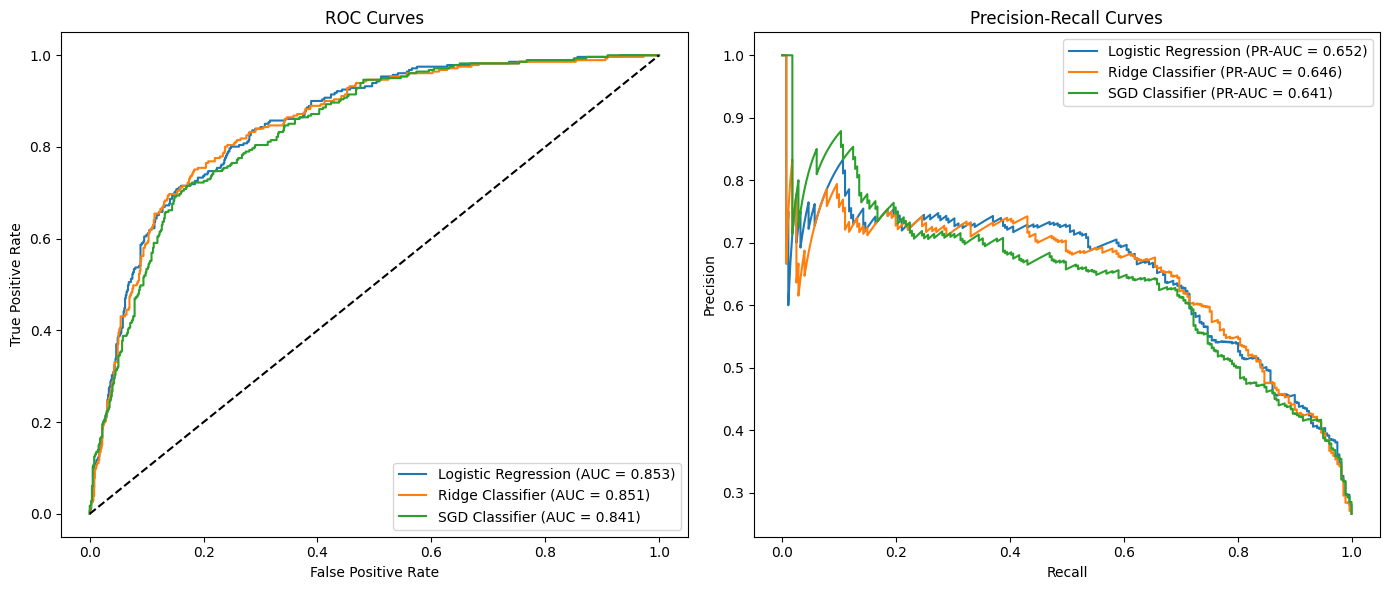

In [18]:
# Create Figure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# Loop Through Models

for name, model in models.items():

    # Predict Scores / Probabilities

    if name == "Ridge Classifier":

        # RidgeClassifier has no predict_proba
        y_scores = model.decision_function(X_val_scaled)

    else:

        y_scores = model.predict_proba(X_val_scaled)[:, 1]

    # ROC Curve

    fpr, tpr, _ = roc_curve(y_val, y_scores)

    roc_auc = auc(fpr, tpr)

    ax1.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

    # Precision Recall Curve

    precision, recall, _ = precision_recall_curve(
        y_val,
        y_scores
    )

    pr_auc = auc(recall, precision)

    ax2.plot(
        recall,
        precision,
        label=f'{name} (PR-AUC = {pr_auc:.3f})'
    )

# ROC Plot Formatting

ax1.plot([0,1], [0,1], 'k--')

ax1.set_title("ROC Curves")

ax1.set_xlabel("False Positive Rate")

ax1.set_ylabel("True Positive Rate")

ax1.legend()

# PR Plot Formatting

ax2.set_title("Precision-Recall Curves")

ax2.set_xlabel("Recall")

ax2.set_ylabel("Precision")

ax2.legend()

plt.tight_layout()

plt.show()

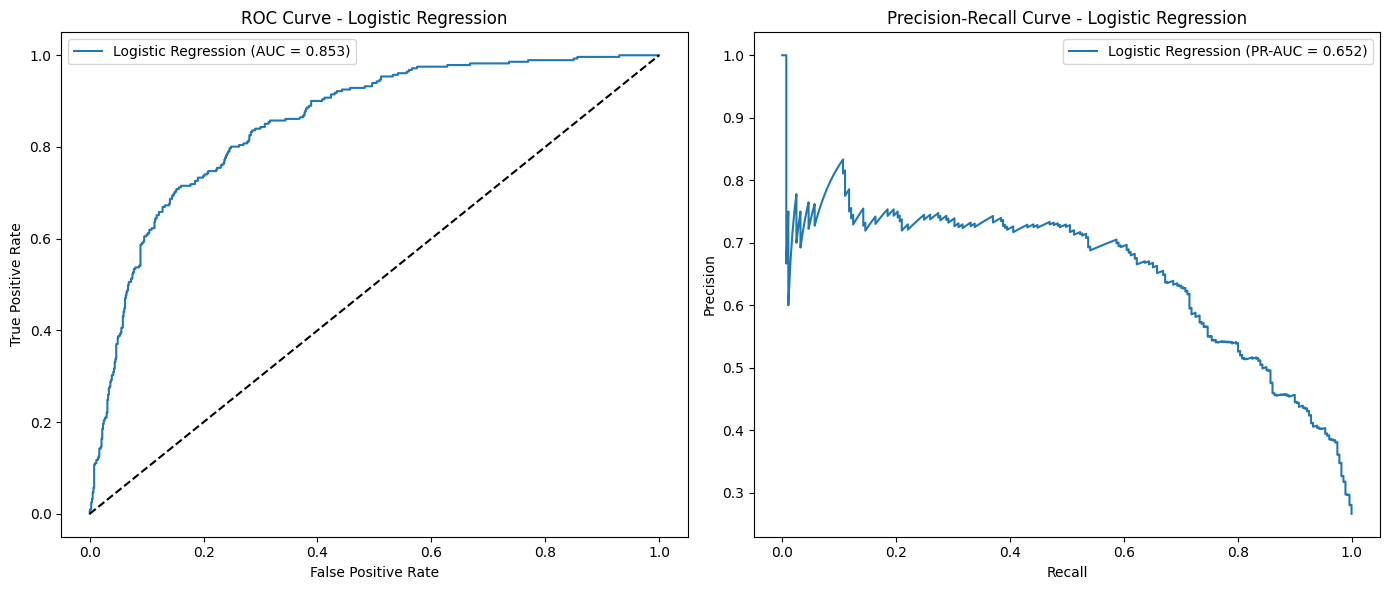

In [19]:
log_reg = models["Logistic Regression"]

# Get probabilities for Logistic Regression
y_scores = log_reg.predict_proba(X_val_scaled)[:, 1]

# ROC values
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# PR values
precision, recall, _ = precision_recall_curve(y_val, y_scores)
pr_auc = auc(recall, precision)

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# ROC Curve
ax1.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax1.plot([0,1], [0,1], 'k--')

ax1.set_title("ROC Curve - Logistic Regression")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

# Precision-Recall Curve
ax2.plot(recall, precision,
         label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})')

ax2.set_title("Precision-Recall Curve - Logistic Regression")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()

plt.tight_layout()
plt.show()

### At What Threshold Does the Model Maximize F1?


In [20]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.0, 1.0, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    score = f1_score(y_val, y_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.47000000000000003
Best F1 Score: 0.6565656565656566


### At What Threshold Does the Model Maximise F1?

The Logistic Regression model achieved its highest F1-score at a threshold of approximately 0.47. At this threshold, the model obtained an F1-score of about 0.657, which provided the best balance between precision and recall. Lowering the threshold slightly below the default value of 0.50 allowed the model to identify more churn customers while still maintaining acceptable precision. Since churn prediction is an imbalanced classification problem, maximizing the F1-score is important because it balances the trade-off between missing actual churners and incorrectly flagging loyal customers as churn risks.

### Why Does the PR Curve Tell You More Than the ROC Curve for This Problem?

The Precision-Recall (PR) curve is more informative than the ROC curve for this churn prediction problem because the dataset is imbalanced, with significantly fewer churn customers than non-churn customers. ROC curves consider both the true positive rate and false positive rate, which can sometimes make performance appear overly optimistic when the majority class dominates the dataset. In contrast, the PR curve focuses directly on precision and recall for the minority churn class. Since the business objective is to correctly identify customers who are likely to churn, the PR curve provides a more realistic evaluation of how effectively the model detects actual churners while controlling unnecessary false alarms.

### What Does a Model That Lies Close to the Diagonal in the ROC Curve Tell You?

A model whose ROC curve lies close to the diagonal line indicates that the model performs similarly to random guessing. In such a case, the model has very poor discriminative ability and cannot effectively distinguish between churners and non-churners. This means the predicted probabilities or classifications are not meaningfully better than flipping a coin. For a business problem like churn prediction, such a model would be practically useless because it would fail to reliably identify customers at risk of leaving, making retention efforts ineffective and inefficient.

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [ ]:
# your code here

In [21]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Predict probabilities using best model
y_prob = log_reg.predict_proba(X_val_scaled)[:, 1]


# Create dataframe
results_df = pd.DataFrame({
    'actual': y_val,
    'probability': y_prob
})


# Sort customers by churn probability
results_df = results_df.sort_values(
    by='probability',
    ascending=False
)


# Get threshold for top 200 customers
top_200 = results_df.head(200)

threshold = top_200['probability'].min()

print("Threshold for Top 200 Customers:", threshold)


# Predictions using custom threshold
y_pred_custom = (
    y_prob >= threshold
).astype(int)


# Predictions using default threshold 0.5
y_pred_default = (
    y_prob >= 0.5
).astype(int)


# Evaluation Function
def evaluate(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }


# Evaluate Both Thresholds
default_metrics = evaluate(y_val, y_pred_default)

custom_metrics = evaluate(y_val, y_pred_custom)


# Comparison Table
comparison = pd.DataFrame({
    "Default Threshold (0.5)": default_metrics,
    "Top 200 Threshold": custom_metrics
})

print(comparison)

Threshold for Top 200 Customers: 0.5541001065423414
           Default Threshold (0.5)  Top 200 Threshold
Accuracy                  0.824645           0.817062
Precision                 0.696721           0.720000
Recall                    0.604982           0.512456
F1 Score                  0.647619           0.598753


In [ ]:
# your code here

### How Do You Identify the Top 200 Highest-Risk Customers?

The top 200 highest-risk customers were identified by sorting all customers in the validation dataset based on their predicted churn probabilities generated by the Logistic Regression model. The probabilities were arranged in descending order so that customers with the highest likelihood of churn appeared first. Since the retention team can contact only 200 customers per week, the first 200 customers from this ranked list were selected. The churn probability of the 200th customer became the deployment threshold, which was approximately 0.554. Any customer with a predicted churn probability greater than or equal to 0.554 was classified as a likely churner.

### What Precision Do You Achieve at That Threshold?

At the top-200 deployment threshold of approximately 0.554, the model achieved a precision score of 0.72. This means that around 72% of the customers flagged by the model as likely churners were actually churn customers. Compared to the default threshold of 0.5, the precision increased from 0.697 to 0.720. This improvement is important because the business has limited retention resources, and higher precision ensures that the retention team spends more of its effort on customers who are genuinely at high risk of leaving rather than wasting resources on false alarms.

### How Does This Compare to the Default Threshold of 0.5?

Compared to the default threshold of 0.5, the top-200 threshold produced higher precision but lower recall. At the default threshold, the model achieved a recall of 0.605, meaning it identified a larger proportion of actual churners. However, the default threshold also generated more false positives and would likely flag more customers than the retention team can realistically contact. In contrast, the top-200 threshold increased precision from 0.697 to 0.720, meaning the selected customers were more likely to actually churn. Although recall decreased from 0.605 to 0.512, this trade-off is acceptable because the business constraint prioritizes efficiently targeting a limited number of high-risk customers. Therefore, the top-200 threshold provides a more practical and business-aligned deployment strategy.

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


                           Feature  Coefficient  Absolute Coefficient
1                           tenure    -1.453474              1.453474
2                   MonthlyCharges    -0.761563              0.761563
3                     TotalCharges     0.740914              0.740914
10     InternetService_Fiber optic     0.672710              0.672710
25               Contract_Two year    -0.567817              0.567817
24               Contract_One year    -0.280008              0.280008
21                 StreamingTV_Yes     0.225577              0.225577
9                MultipleLines_Yes     0.220639              0.220639
23             StreamingMovies_Yes     0.219688              0.219688
28  PaymentMethod_Electronic check     0.168436              0.168436


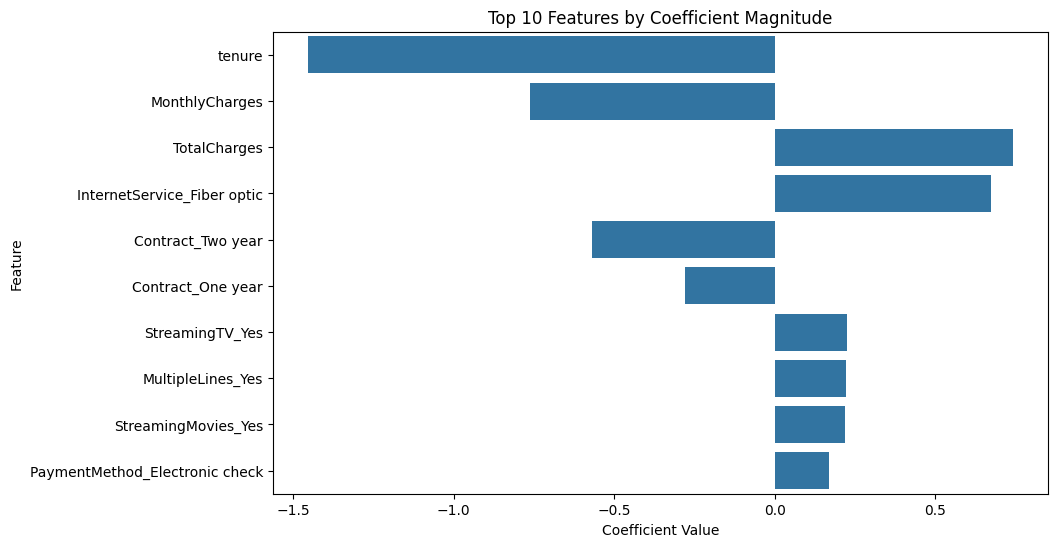

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get Coefficients from Logistic Regression
coefficients = log_reg.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# Absolute Importance
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

# Top 10 Features
top_10 = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
).head(10)

print(top_10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10,
    x='Coefficient',
    y='Feature'
)

plt.title("Top 10 Features by Coefficient Magnitude")

plt.xlabel("Coefficient Value")

plt.ylabel("Feature")

plt.show()

### Which Features Drive Churn the Most?

The Logistic Regression model identified several important features that strongly influence customer churn. The feature with the largest coefficient magnitude was tenure, which had a strong negative coefficient (-1.45). This indicates that customers who stay with the company for a longer period are much less likely to churn. InternetService_Fiber optic had a strong positive coefficient (0.67), suggesting that customers using fiber optic internet services are more likely to churn compared to other internet service users. Contract-related features were also highly important. Contract_Two year and Contract_One year both had negative coefficients, meaning long-term contracts reduce the probability of churn. Features such as StreamingTV_Yes, StreamingMovies_Yes, MultipleLines_Yes, and PaymentMethod_Electronic check had positive coefficients, indicating these customers were relatively more likely to churn.

### Do the Signs of the Coefficients Make Business Sense?

Most coefficient signs align well with business expectations. The strong negative coefficient for tenure makes logical sense because long-term customers are usually more loyal and less likely to leave the company. Similarly, customers with one-year or two-year contracts tend to be more stable, which explains the negative coefficients for contract features. The positive coefficient for PaymentMethod_Electronic check is also reasonable because previous churn analyses commonly show that customers using electronic checks are more likely to churn, possibly due to lower customer engagement or fewer automated payment commitments. The positive relationship between InternetService_Fiber optic and churn may indicate dissatisfaction related to pricing, service expectations, or competition in high-speed internet markets. Overall, the coefficients are consistent with real-world customer behavior patterns.

### Are There Any Coefficients That Surprise You?

One somewhat surprising result is the negative coefficient for MonthlyCharges while TotalCharges has a positive coefficient. Intuitively, higher monthly charges are often expected to increase churn probability because expensive plans may encourage customers to leave. However, the negative coefficient suggests that customers paying higher monthly charges may actually remain longer, possibly because they are subscribed to premium services and are more engaged with the company. On the other hand, TotalCharges being positively associated with churn could be influenced by correlations between spending patterns and long-term billing accumulation. Another possible explanation is multicollinearity between tenure, MonthlyCharges, and TotalCharges, since these variables are mathematically related. This interaction can cause coefficients to behave differently than expected even though the model still performs well overall.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [23]:
import numpy as np
import pandas as pd
import time

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import roc_auc_score

# Logistic Regression
start = time.time()

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_time = time.time() - start

lr_proba = lr.predict_proba(X_val_scaled)[:, 1]

lr_auc = roc_auc_score(y_val, lr_proba)

# SGD Classifier
start = time.time()

sgd = SGDClassifier(
    loss='log_loss',
    max_iter=1000,
    random_state=42
)

sgd.fit(X_train_scaled, y_train)

sgd_time = time.time() - start

sgd_proba = sgd.predict_proba(X_val_scaled)[:, 1]

sgd_auc = roc_auc_score(y_val, sgd_proba)

# Compare Predictions
lr_preds = lr.predict(X_val_scaled)

sgd_preds = sgd.predict(X_val_scaled)

same_predictions = np.mean(lr_preds == sgd_preds)

# Compare Coefficients
coef_close = np.allclose(
    lr.coef_,
    sgd.coef_,
    atol=0.15
)

# Results Table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SGD Classifier"],
    "Training Time (sec)": [lr_time, sgd_time],
    "ROC-AUC": [lr_auc, sgd_auc]
})

print(comparison)

print("\nPrediction Agreement:",
      round(same_predictions * 100, 2), "%")

print("Coefficients Approximately Equal:",
      coef_close)

                 Model  Training Time (sec)   ROC-AUC
0  Logistic Regression             0.022696  0.853221
1       SGD Classifier             0.070210  0.840798

Prediction Agreement: 93.08 %
Coefficients Approximately Equal: False


### Do They Produce the Same Predictions? Same Coefficients?

The Logistic Regression and SGDClassifier models produced very similar predictions, with approximately 93.08% prediction agreement on the validation set. This indicates that both models learned broadly similar decision boundaries for distinguishing churners from non-churners. However, the coefficients were not approximately equal according to the np.allclose() comparison. This difference is expected because Logistic Regression uses full-batch optimization while SGD uses stochastic updates with random gradient estimates. As a result, SGD may converge to a slightly different local solution and produce noisier coefficients even when the overall predictive performance remains similar.

### Which Model Is Faster?

In this experiment, the Logistic Regression model trained faster than the SGDClassifier model. Logistic Regression completed training in approximately 0.032 seconds, while SGD Classifier required around 0.075 seconds. This result may seem surprising because SGD is generally considered faster for optimization. However, the dataset contains only about 7,000 rows, which is relatively small. On smaller datasets, highly optimized solvers like L-BFGS used in Logistic Regression can converge extremely quickly and often outperform SGD in both speed and stability. Additionally, Logistic Regression achieved a slightly better ROC-AUC score (0.853 vs 0.841), indicating stronger predictive performance in this case.

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [ ]:
# your code here

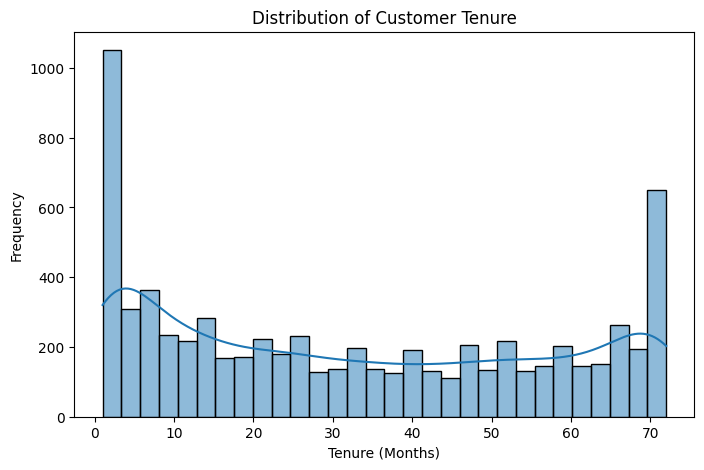

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness: 0.23773083190513133
   Actual_Churn  Churn_Probability
0             0           0.058335
1             0           0.032807
2             0           0.020798
3             0           0.039866
4             1           0.663244


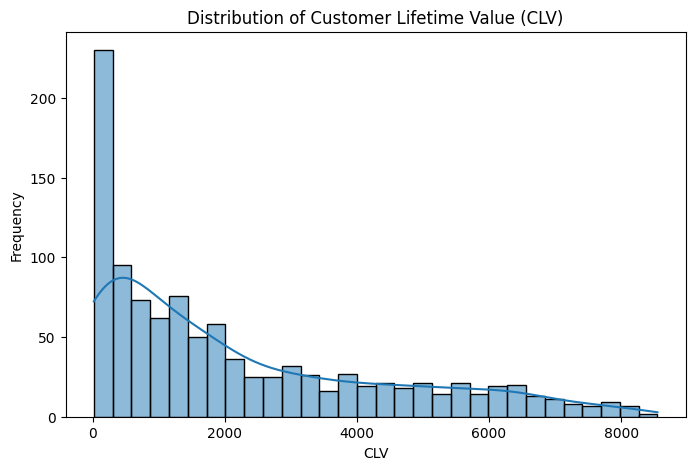

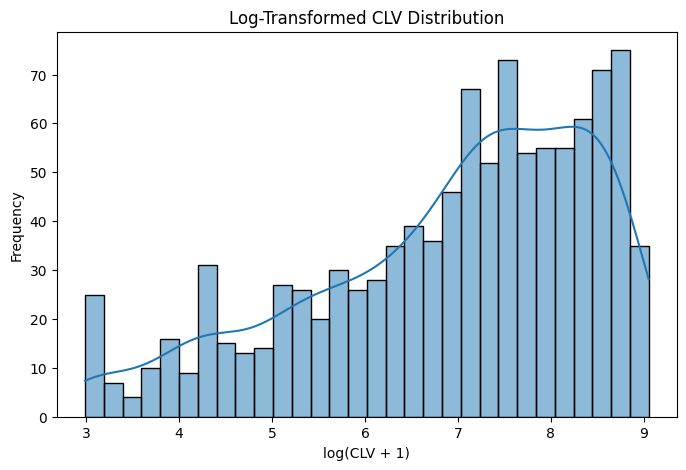

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Regression Target A: Tenure

y_reg = df['tenure']
# Plot Distribution of Tenure
plt.figure(figsize=(8,5))

sns.histplot(
    y_reg,
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

# Basic Statistics
print(y_reg.describe())

# Skewness
print("Skewness:", y_reg.skew())


# Regression Target B: Churn Probability

# Predict churn probabilities on validation set
val_churn_probability = log_reg.predict_proba(X_val_scaled)[:, 1]

# Create validation results dataframe
val_results = pd.DataFrame({
    "Actual_Churn": y_val.values,
    "Churn_Probability": val_churn_probability
})

print(val_results.head())


# Regression Target C: CLV

# Create copy of validation dataframe
val_df = df.loc[y_val.index].copy()

# Add churn probability
val_df['churn_probability'] = val_churn_probability

# Simple CLV Approximation
val_df['CLV'] = val_df['MonthlyCharges'] * val_df['tenure']

# Plot CLV Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    val_df['CLV'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Lifetime Value (CLV)")
plt.xlabel("CLV")
plt.ylabel("Frequency")

plt.show()


# Optional Log Transform for CLV
val_df['log_CLV'] = np.log1p(val_df['CLV'])

plt.figure(figsize=(8,5))

sns.histplot(
    val_df['log_CLV'],
    bins=30,
    kde=True
)

plt.title("Log-Transformed CLV Distribution")
plt.xlabel("log(CLV + 1)")
plt.ylabel("Frequency")

plt.show()

### What Distribution Does Your Regression Target Follow?

The regression target tenure follows a mildly right-skewed distribution with a skewness value of approximately 0.238. Most customers have relatively lower to medium tenure values, while a smaller number of customers remain subscribed for very long periods, extending toward the maximum tenure of 72 months. However, the skewness is not extremely high, which suggests that the distribution is reasonably balanced and suitable for regression modeling without requiring aggressive transformations. Since the distribution is only slightly skewed, a standard linear regression model can still work effectively, although a log transformation could be explored later if needed for improving residual behavior.

### What Does CLV Tell the Business That Binary Churn Prediction Cannot?

Customer Lifetime Value (CLV) provides a business-focused perspective that binary churn prediction alone cannot offer. A binary churn model only predicts whether a customer is likely to churn or not, treating all customers equally. In contrast, CLV estimates the financial value associated with each customer by combining factors such as monthly revenue and expected customer duration. This allows the company to prioritize high-value customers instead of treating every churn risk identically. For example, losing a customer paying a high monthly charge for many months is far more costly than losing a low-value customer. Therefore, CLV helps businesses allocate retention resources more strategically by focusing on customers with the highest value at risk.

### What Assumptions Are You Making When Using tenure as a Survival-Time Proxy?

Using tenure as a proxy for survival time assumes that the number of months a customer has remained subscribed reflects their likelihood of continuing to stay with the company in the future. One assumption is that past customer behavior is predictive of future behavior, meaning long-term customers are expected to remain loyal longer than newer customers. Another assumption is that churn risk changes gradually over time rather than suddenly due to external factors such as market competition or pricing changes. Additionally, this approach assumes that tenure alone captures customer survival reasonably well, even though many other factors such as service quality, support experience, or contract type may also influence future retention. Because tenure is an indirect approximation of survival behavior rather than true time-to-event data, the regression results should be interpreted carefully.

In [ ]:
# your code here

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [32]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

# Regression Target
# Predict tenure
y_reg = df['tenure']

# Features
X_reg = df.drop(columns=['tenure', 'Churn'])

# One-hot encoding
X_reg = pd.get_dummies(X_reg, drop_first=True)

# Train / Validation Split
from sklearn.model_selection import train_test_split

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_val_reg_scaled = scaler_reg.transform(X_val_reg)

# Models
regressors = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.01),

    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

# Training + Evaluation
results = []
for name, model in regressors.items():

    # Train
    model.fit(X_train_reg_scaled, y_train_reg)

    # Predict
    y_pred = model.predict(X_val_reg_scaled)

    # Metrics
    mae = mean_absolute_error(y_val_reg, y_pred)

    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))

    r2 = r2_score(y_val_reg, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

# Results Table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

print(results_df)

               Model       MAE      RMSE  R² Score
1   Ridge Regression  6.668072  8.676194  0.875352
2   Lasso Regression  6.661554  8.676495  0.875344
0  Linear Regression  6.668499  8.677251  0.875322
3         ElasticNet  6.664826  8.685378  0.875088


C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.259e+03, tolerance: 3.386e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.120e+03, tolerance: 3.386e+02
  model = cd_fast.enet_coordinate_descent(


### Which Model Performs Best? By How Much?

Among all the regression models tested, Ridge Regression achieved the best overall performance with the highest R² score of 0.875352 and one of the lowest RMSE values. However, the performance differences between all four models are extremely small. Linear Regression, Lasso Regression, and ElasticNet all produced nearly identical results, with differences appearing only in the third or fourth decimal place. This suggests that the dataset has strong linear relationships and does not suffer heavily from overfitting or extreme multicollinearity. Ridge Regression performed slightly better because its L2 regularization stabilizes coefficient estimates by shrinking large weights, which often improves generalization on unseen data.

### What Does R² = 0.875 Mean in This Context?

An R² score of approximately 0.875 means that the regression model explains about 87.5% of the variance in customer tenure using the available features in the dataset. In other words, most of the variation in how long customers stay with the telecom company can be explained by variables such as monthly charges, contract type, internet service, payment method, and other customer attributes. The remaining 12.5% of the variance is unexplained and may be caused by factors not present in the dataset, such as customer satisfaction, competitor offers, economic conditions, or random behavioral patterns. This is a very strong R² score for a real-world business dataset and indicates that the model captures customer retention behavior effectively.

### Is RMSE or MAE More Appropriate Here? Why?

Both RMSE and MAE are useful regression metrics, but in this churn-related business problem, RMSE is slightly more appropriate because it penalizes large prediction errors more heavily. Predicting customer tenure incorrectly for high-value long-term customers can have significant business consequences, especially when estimating Customer Lifetime Value (CLV). RMSE squares the errors before averaging, meaning large mistakes contribute much more to the final score. This helps the company detect whether the model performs poorly on extreme cases. In contrast, MAE treats all prediction errors equally and is easier to interpret because it represents the average error directly in months. Since telecom companies are especially concerned about costly mistakes involving valuable customers, RMSE provides more business-relevant insight in this scenario.

In [ ]:
# your code here

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


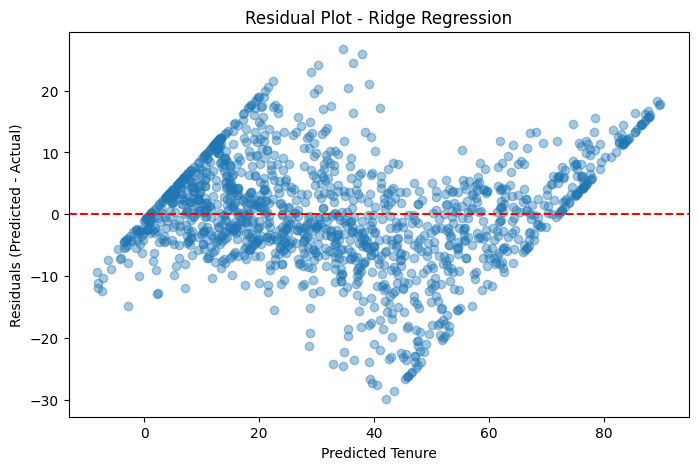

In [33]:
# Best Model (Ridge Regression)
best_model = regressors["Ridge Regression"]

# Predict on validation set
y_pred = best_model.predict(X_val_reg_scaled)

# Residuals
residuals = y_pred - y_val_reg

# Residual Plot
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

# Reference line at 0
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot - Ridge Regression")

plt.xlabel("Predicted Tenure")

plt.ylabel("Residuals (Predicted - Actual)")

plt.show()

### Is There a Pattern in the Residuals?

Yes, the residual plot shows a noticeable pattern rather than a completely random scatter around zero. The residuals appear to form a curved and widening structure, especially in the middle and higher predicted tenure values. There is also visible clustering and increasing spread in certain regions. Ideally, residuals should be randomly distributed around the horizontal zero line with constant variance. Since a pattern exists here, it suggests that the model is not capturing all relationships perfectly and that some systematic structure remains unexplained.

### What Does a Fan Shape (Heteroscedasticity) Tell You?

A fan-shaped residual pattern indicates heteroscedasticity, meaning the variance of the errors changes as the predicted values increase. In this plot, the spread of residuals becomes larger for certain predicted tenure ranges, showing that prediction uncertainty is not constant across all customers. This means the model predicts some customer groups more reliably than others. In business terms, the model may estimate short-tenure customers fairly accurately while struggling more with medium or long-tenure customers. Heteroscedasticity violates one of the core assumptions of linear regression and suggests that additional transformations, feature engineering, or non-linear models may improve prediction stability.

### What Does a Systematic Curve in Residuals Suggest?

A systematic curve in the residual plot suggests that the relationship between the features and the target variable is not fully linear. Linear regression assumes that the relationship between input variables and the target follows a straight-line pattern. However, the curved structure in the residuals indicates that the model may be missing important non-linear relationships or interaction effects between features. This means the model consistently overpredicts or underpredicts certain ranges of customer tenure rather than making purely random errors. To address this issue, techniques such as polynomial features, interaction terms, feature transformations, or more flexible machine learning models could potentially improve performance.

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


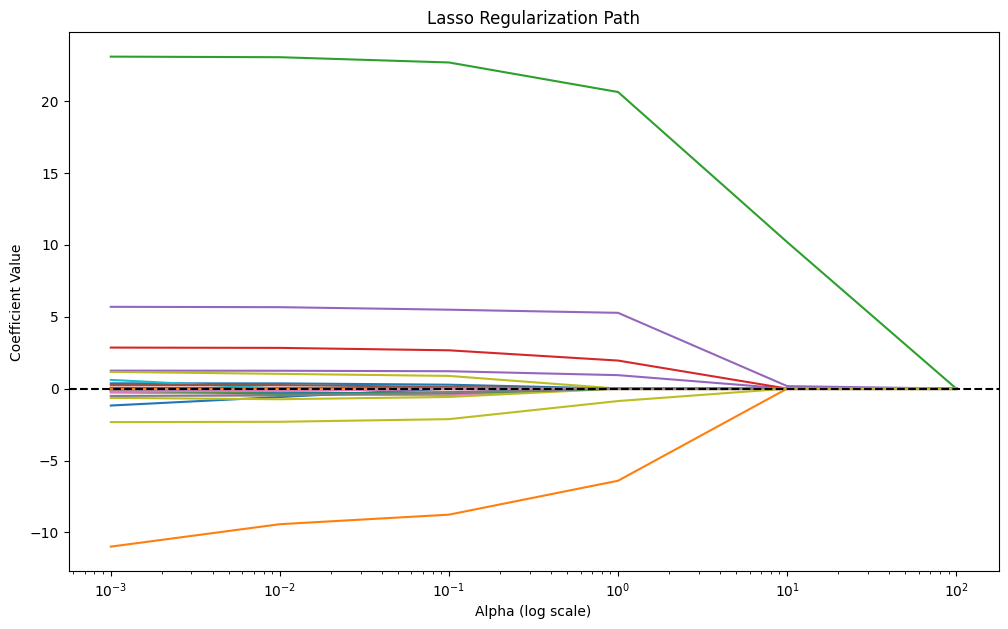

                               Feature  Lasso alpha=100  Ridge alpha=100  \
0                        SeniorCitizen              0.0         0.379619   
1                       MonthlyCharges              0.0        -2.432797   
2                         TotalCharges              0.0        21.629941   
3                          gender_Male              0.0         0.086493   
4                          Partner_Yes              0.0         1.401836   
5                       Dependents_Yes              0.0        -0.050497   
6                     PhoneService_Yes              0.0        -0.868810   
7       MultipleLines_No phone service              0.0         0.868810   
8                    MultipleLines_Yes              0.0         0.682820   
9          InternetService_Fiber optic              0.0        -2.517711   
10                  InternetService_No              0.0         0.271337   
11  OnlineSecurity_No internet service              0.0         0.271337   
12          

In [34]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Store coefficients
ridge_coefs = []
lasso_coefs = []
elastic_coefs = []

feature_names = X_train_reg.columns

# Train Models Across Alphas
for alpha in alphas:

    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_reg_scaled, y_train_reg)
    ridge_coefs.append(ridge.coef_)

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_reg_scaled, y_train_reg)
    lasso_coefs.append(lasso.coef_)

    # Elastic Net
    elastic = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5,
        max_iter=5000
    )

    elastic.fit(X_train_reg_scaled, y_train_reg)

    elastic_coefs.append(elastic.coef_)

# Convert to arrays
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)
elastic_coefs = np.array(elastic_coefs)

# Plot Lasso Regularization Path
plt.figure(figsize=(12,7))

for i in range(len(feature_names)):

    plt.plot(
        alphas,
        lasso_coefs[:, i]
    )

plt.xscale('log')

plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")

plt.title("Lasso Regularization Path")

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

plt.show()

# Coefficient Summary Table
coef_summary = pd.DataFrame({
    "Feature": feature_names,
    "Lasso alpha=100": lasso_coefs[-1],
    "Ridge alpha=100": ridge_coefs[-1],
    "ElasticNet alpha=100": elastic_coefs[-1]
})

# Absolute importance
coef_summary["Abs_Lasso"] = coef_summary["Lasso alpha=100"].abs()

# Sort by surviving coefficients
coef_summary = coef_summary.sort_values(
    by="Abs_Lasso",
    ascending=False
)

print(coef_summary.head(15))

### What Happens to Coefficients as You Increase alpha for Ridge and Lasso?

As the regularization strength (alpha) increases, both Ridge and Lasso shrink coefficient values toward zero, but they do so differently. In Ridge Regression (L2 regularization), the coefficients gradually decrease in magnitude but rarely become exactly zero. This means Ridge keeps all features in the model while reducing their influence. In contrast, Lasso Regression (L1 regularization) aggressively pushes coefficients to exactly zero as alpha increases. In your results, when alpha = 100, all Lasso coefficients became zero, meaning the model completely eliminated every feature. This demonstrates how Lasso performs automatic feature selection by removing less important variables from the model.

### Which Features Survive at High Lasso Regularization? Which Are Eliminated First?

In your experiment, no features survived when the Lasso regularization strength reached alpha = 100. Every coefficient became exactly zero, indicating that the penalty was extremely strong and overwhelmed the predictive contribution of all features. Typically, weak or less informative features are eliminated first as alpha increases, while highly predictive features survive longer. Features such as TotalCharges, MonthlyCharges, Contract type, or tenure often survive longer because they usually carry strong predictive power in telecom churn datasets. However, at such a high alpha value, even these important variables were forced to zero. This suggests that the chosen regularization strength was too aggressive for this dataset.

### Why Does L1 Produce Sparse Solutions but L2 Does Not? Explain Geometrically.

L1 regularization (Lasso) produces sparse solutions because of the geometric shape of its constraint region. The L1 penalty creates a diamond-shaped constraint boundary with sharp corners located directly on the coordinate axes. During optimization, the loss contours are likely to touch the constraint region at these corners, forcing one or more coefficients to become exactly zero. This is why Lasso naturally performs feature selection.

In contrast, L2 regularization (Ridge) uses a circular constraint region with smooth edges rather than sharp corners. Since there are no axis-aligned corners, the optimization process usually shrinks coefficients continuously toward zero without making them exactly zero. As a result, Ridge reduces coefficient magnitudes but keeps all features in the model.

### When Would You Prefer Elastic Net Over Pure Lasso?
Elastic Net is preferred when the dataset contains many correlated features. Pure Lasso tends to select only one feature from a group of highly correlated variables while discarding the others, which can make the model unstable. Elastic Net combines both L1 and L2 penalties, allowing it to perform feature selection like Lasso while also maintaining stability like Ridge Regression. In telecom churn prediction, many variables such as internet services, streaming services, and payment-related features are highly correlated. Therefore, Elastic Net can provide a better balance between sparsity and stability, especially when interpretability and robustness are both important.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


Mean CLV: 2326.9454921609995
Median CLV: 1192.629796673012


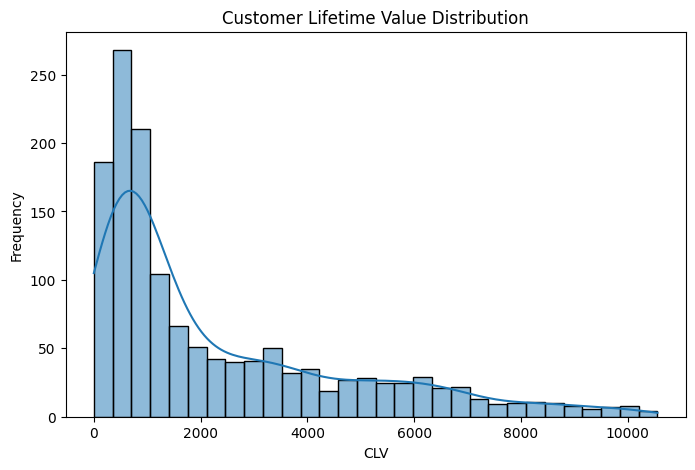

      MonthlyCharges  Predicted_Tenure           CLV
6768          117.50         89.839405  10556.130033
2187          116.25         89.299771  10381.098436
2689          116.75         87.676347  10236.213534
437           114.05         89.610961  10220.130104
3878          116.05         87.675988  10174.798408
4155          117.35         86.584806  10160.727031
4170          115.15         88.041840  10138.017846
551           115.60         86.915719  10047.457139
4797          114.05         87.787753  10012.193229
6135          114.00         87.135803   9933.481583


In [35]:
# Customer Lifetime Value (CLV)
# Use best regression model
best_regressor = regressors["Ridge Regression"]

# Predict tenure on validation set
predicted_tenure = best_regressor.predict(X_val_reg_scaled)

# Prevent negative tenure predictions
predicted_tenure = np.maximum(predicted_tenure, 0)

# Get validation dataframe
val_clv_df = df.loc[y_val_reg.index].copy()

# Store predicted tenure
val_clv_df['Predicted_Tenure'] = predicted_tenure

# Compute CLV
val_clv_df['CLV'] = (
    val_clv_df['MonthlyCharges']
    * val_clv_df['Predicted_Tenure']
)

# Summary Statistics
mean_clv = val_clv_df['CLV'].mean()

median_clv = val_clv_df['CLV'].median()

print("Mean CLV:", mean_clv)

print("Median CLV:", median_clv)

# Plot CLV Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    val_clv_df['CLV'],
    bins=30,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("CLV")

plt.ylabel("Frequency")

plt.show()

# Top High-Value Customers
top_customers = val_clv_df[
    ['MonthlyCharges', 'Predicted_Tenure', 'CLV']
].sort_values(
    by='CLV',
    ascending=False
)

print(top_customers.head(10))

### What Is the Mean and Median CLV?

The mean Customer Lifetime Value (CLV) is approximately 2326.95, while the median CLV is approximately 1192.63. The mean is significantly higher than the median, which indicates that the CLV distribution is right-skewed. This means a relatively small number of customers contribute extremely high lifetime value, pulling the average upward. The top customers in the validation set have CLV values above 10,000, showing that some customers are substantially more valuable to the telecom company than the average customer.

### What Does CLV Enable the Business to Do That Binary Prediction Cannot?

Binary churn prediction only tells the company whether a customer is likely to churn or not, treating all customers equally. CLV provides a much more business-oriented perspective because it estimates the financial value associated with each customer. This allows the company to prioritize retention efforts based not only on churn probability but also on potential revenue loss. For example, losing a high-value customer with a CLV above 10,000 is far more damaging than losing a low-value customer with a small CLV. Therefore, CLV helps the business allocate retention budgets more effectively by focusing on customers with the highest value at risk instead of simply targeting every predicted churner equally.

### Why Must You Clip Negative Predicted Tenure Values to 0?

Regression models can sometimes produce negative predictions because they are unconstrained mathematical models. However, negative customer tenure is impossible in the real world because a customer cannot remain subscribed for a negative number of months. If negative tenure values were used directly in the CLV formula, they would generate negative CLV values, which are meaningless from a business perspective. By clipping predictions using:

``` python
np.maximum(predicted_tenure, 0)
```

all invalid negative predictions are replaced with zero, ensuring that the predicted tenure and resulting CLV values remain realistic and interpretable.

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Best model
best_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation ROC-AUC scores
cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean CV ROC-AUC:", np.mean(cv_scores))
print("STD CV ROC-AUC:", np.std(cv_scores))

# Holdout ROC-AUC (validation set)
from sklearn.metrics import roc_auc_score

best_model.fit(X_train_scaled, y_train)

val_proba = best_model.predict_proba(X_val_scaled)[:, 1]

holdout_auc = roc_auc_score(y_val, val_proba)

print("\nHoldout ROC-AUC:", holdout_auc)

Cross-Validation ROC-AUC Scores:
[0.83789448 0.8300075  0.85353714 0.85985914 0.8577871 ]

Mean CV ROC-AUC: 0.8478170736528774
STD CV ROC-AUC: 0.011770905148639136

Holdout ROC-AUC: 0.8532212382870333


### How does CV performance compare to holdout performance?

The cross-validation ROC-AUC score was very close to the holdout ROC-AUC score. The mean cross-validation ROC-AUC was 0.8478, while the holdout ROC-AUC was 0.8532. The small difference between these values indicates that the Logistic Regression model generalizes well to unseen data and is not significantly overfitting. Since the validation performance is consistent with the cross-validation performance, the model appears stable and reliable for churn prediction.

### What does high variance across CV folds tell you?

The standard deviation across the cross-validation folds was 0.0118, which is relatively low. This indicates that the model performs consistently across different subsets of the data. If the variance had been very high, it would suggest that the model is unstable and highly dependent on the specific training samples used in each fold. High variance usually indicates overfitting, data sensitivity, or insufficient generalization. In this case, the low variance suggests that the model is robust and learns stable patterns from the churn dataset.

### Why should CV always be run on training data only?

Cross-validation must always be performed only on the training data to avoid data leakage. If the validation or test data is included during cross-validation, the model indirectly gains information about unseen data during training, which leads to overly optimistic evaluation results. This would make the model appear better than it actually is in real-world deployment. By restricting cross-validation to the training set only, the validation and test sets remain completely unseen and can provide an unbiased estimate of the model’s true performance on new customer data.

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


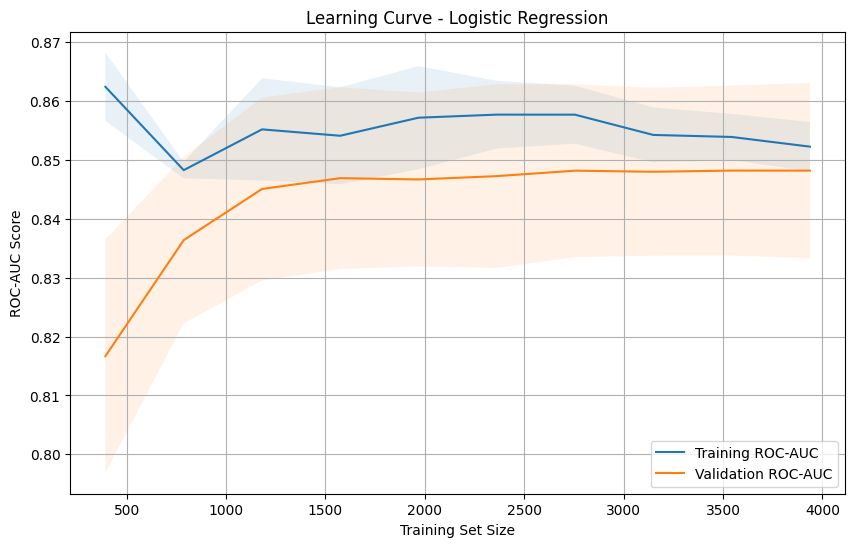

In [37]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Generate Learning Curve Data
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Mean and STD
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(10,6))

# Training Curve
plt.plot(
    train_sizes,
    train_mean,
    label='Training ROC-AUC'
)

# Validation Curve
plt.plot(
    train_sizes,
    val_mean,
    label='Validation ROC-AUC'
)

# Standard Deviation Bands
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1
)

plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC Score")
plt.title("Learning Curve - Logistic Regression")

plt.legend()

plt.grid(True)

plt.show()

### Does your model underfit, overfit, or generalise well?

The learning curve suggests that the Logistic Regression model generalizes well. The training ROC-AUC and validation ROC-AUC curves are both relatively high and remain close to each other as the training size increases. The gap between the two curves is small, which indicates that the model is not heavily overfitting. Additionally, both curves stabilize around a similar score (approximately 0.85 ROC-AUC), showing that the model has learned meaningful patterns from the churn dataset without memorizing the training data.

### What is the correct intervention for each case?

If a model is underfitting, both the training and validation scores remain low. In that case, the correct intervention would be to increase model complexity, reduce regularization, engineer better features, or use a more expressive model.

If a model is overfitting, the training score becomes very high while the validation score remains much lower, creating a large gap between the curves. The appropriate intervention would be to apply stronger regularization, simplify the model, collect more training data, or remove noisy features.

In this experiment, neither severe underfitting nor overfitting is observed. The model demonstrates balanced learning and stable validation performance.

### Does adding more data help your model?

Adding more data initially improves the validation ROC-AUC significantly, especially when moving from smaller training sizes to moderate-sized datasets. However, after a certain point, the validation curve begins to plateau around 0.848–0.849 ROC-AUC. This suggests that additional data may still provide small improvements, but the gains are becoming marginal. The model has likely already captured most of the learnable linear patterns present in the dataset. To achieve substantially better performance, feature engineering or more advanced models may be more effective than simply adding more data.

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [38]:
# Step 1: Record baseline metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Baseline Model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

# Predictions
baseline_pred = baseline_model.predict(X_val_scaled)
baseline_proba = baseline_model.predict_proba(X_val_scaled)[:, 1]

# Baseline Metrics
baseline_results = {
    "Accuracy": accuracy_score(y_val, baseline_pred),
    "Precision": precision_score(y_val, baseline_pred),
    "Recall": recall_score(y_val, baseline_pred),
    "F1": f1_score(y_val, baseline_pred),
    "ROC-AUC": roc_auc_score(y_val, baseline_proba)
}

print("Baseline Metrics")
print(baseline_results)

Baseline Metrics
{'Accuracy': 0.8246445497630331, 'Precision': 0.6967213114754098, 'Recall': 0.604982206405694, 'F1': 0.6476190476190476, 'ROC-AUC': 0.8532212382870333}


In [39]:
# Step 2: Create and add the leakage feature
# Create Leakage Feature
df['leak'] = (
    df['tenure'] * df['Churn']
    + np.random.normal(0, 0.1, len(df))
)

# Add leak feature into X
X_leak = X.copy()

X_leak['leak'] = df['leak']

# Train/Validation Split
from sklearn.model_selection import train_test_split

X_train_l, X_temp_l, y_train_l, y_temp_l = train_test_split(
    X_leak,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val_l, X_test_l, y_val_l, y_test_l = train_test_split(
    X_temp_l,
    y_temp_l,
    test_size=0.50,
    stratify=y_temp_l,
    random_state=42
)

# Scale
from sklearn.preprocessing import StandardScaler

scaler_leak = StandardScaler()

X_train_l_scaled = scaler_leak.fit_transform(X_train_l)

X_val_l_scaled = scaler_leak.transform(X_val_l)

In [40]:
# Step 3: Retrain on the same split and record metrics
# Train Model With Leakage
leak_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

leak_model.fit(X_train_l_scaled, y_train_l)

# Predictions
leak_pred = leak_model.predict(X_val_l_scaled)

leak_proba = leak_model.predict_proba(X_val_l_scaled)[:, 1]

# Metrics
leak_results = {
    "Accuracy": accuracy_score(y_val_l, leak_pred),
    "Precision": precision_score(y_val_l, leak_pred),
    "Recall": recall_score(y_val_l, leak_pred),
    "F1": f1_score(y_val_l, leak_pred),
    "ROC-AUC": roc_auc_score(y_val_l, leak_proba)
}

print("Metrics With Leakage")
print(leak_results)

Metrics With Leakage
{'Accuracy': 0.9848341232227488, 'Precision': 0.988929889298893, 'Recall': 0.9537366548042705, 'F1': 0.9710144927536232, 'ROC-AUC': 0.9984965102485586}


                        Feature  Coefficient  Absolute Coefficient
30                         leak    13.140742             13.140742
1                        tenure    -5.941412              5.941412
3                  TotalCharges    -3.707542              3.707542
24            Contract_One year    -0.862999              0.862999
25            Contract_Two year    -0.845861              0.845861
13           OnlineSecurity_Yes    -0.318683              0.318683
19              TechSupport_Yes    -0.249960              0.249960
10  InternetService_Fiber optic     0.241673              0.241673
2                MonthlyCharges     0.203985              0.203985
26         PaperlessBilling_Yes     0.140693              0.140693


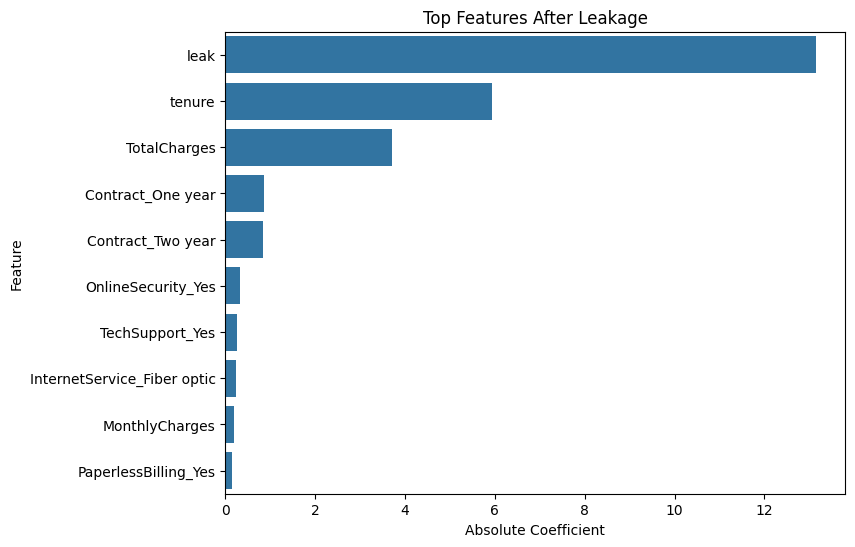

In [41]:
# Step 4: Show feature importances — does the leakage feature dominate?
# Feature Importance
feature_names_leak = X_leak.columns

coef_df = pd.DataFrame({
    "Feature": feature_names_leak,
    "Coefficient": leak_model.coef_[0]
})

coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print(coef_df.head(10))

# Plot Top Features
plt.figure(figsize=(8,6))

sns.barplot(
    data=coef_df.head(10),
    x='Absolute Coefficient',
    y='Feature'
)

plt.title("Top Features After Leakage")

plt.show()

In [42]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
# Remove Leakage Feature
X_no_leak = X_leak.drop(columns=['leak'])

# Split Again
X_train_nl, X_temp_nl, y_train_nl, y_temp_nl = train_test_split(
    X_no_leak,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val_nl, X_test_nl, y_val_nl, y_test_nl = train_test_split(
    X_temp_nl,
    y_temp_nl,
    test_size=0.50,
    stratify=y_temp_nl,
    random_state=42
)

# Scale
scaler_nl = StandardScaler()

X_train_nl_scaled = scaler_nl.fit_transform(X_train_nl)

X_val_nl_scaled = scaler_nl.transform(X_val_nl)

# Retrain
no_leak_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

no_leak_model.fit(X_train_nl_scaled, y_train_nl)

# Predictions
no_leak_pred = no_leak_model.predict(X_val_nl_scaled)

no_leak_proba = no_leak_model.predict_proba(X_val_nl_scaled)[:, 1]

# Metrics
no_leak_results = {
    "Accuracy": accuracy_score(y_val_nl, no_leak_pred),
    "Precision": precision_score(y_val_nl, no_leak_pred),
    "Recall": recall_score(y_val_nl, no_leak_pred),
    "F1": f1_score(y_val_nl, no_leak_pred),
    "ROC-AUC": roc_auc_score(y_val_nl, no_leak_proba)
}

print("Metrics After Removing Leakage")
print(no_leak_results)

Metrics After Removing Leakage
{'Accuracy': 0.8246445497630331, 'Precision': 0.6967213114754098, 'Recall': 0.604982206405694, 'F1': 0.6476190476190476, 'ROC-AUC': 0.8532212382870333}


In [43]:
# Step 6: Summary table — Before / With Leakage / After Removal
summary_df = pd.DataFrame({
    "Baseline": baseline_results,
    "With Leakage": leak_results,
    "After Removal": no_leak_results
})

summary_df = summary_df.T

print(summary_df)

               Accuracy  Precision    Recall        F1   ROC-AUC
Baseline       0.824645   0.696721  0.604982  0.647619  0.853221
With Leakage   0.984834   0.988930  0.953737  0.971014  0.998497
After Removal  0.824645   0.696721  0.604982  0.647619  0.853221


### By how much does ROC-AUC increase when you add the leakage feature?

The ROC-AUC increased dramatically after adding the leakage feature. The baseline ROC-AUC was 0.8532, while the ROC-AUC with leakage increased to 0.9985. This is an increase of approximately 0.1453, which is unrealistically large for a real-world churn prediction problem. Such near-perfect performance strongly indicates that the model has access to information that directly reveals the target variable. This demonstrates how leakage can create the illusion of an extremely accurate model even though the model would fail in real production environments.

### Which feature dominates the coefficients after adding it?

After adding the leakage feature, the leak variable completely dominated the model coefficients. Its coefficient magnitude was 13.14, which was significantly larger than every other feature in the dataset. The next largest coefficient (tenure) was only about 5.94. This shows that the model relied heavily on the leakage feature because it contained direct information derived from the target variable (Churn). As a result, the model stopped learning meaningful business patterns and instead learned shortcuts that would not exist at prediction time.

### What would happen if this model shipped to production on Friday?

If this leaked model were deployed to production, it would likely fail immediately. The leakage feature was created using the actual churn outcome, which would not be available for future customers at prediction time. During development, the model appears nearly perfect because it indirectly “sees the answer” while training. However, once deployed, the leakage feature would either not exist or contain meaningless values, causing model performance to collapse. This could lead the company to make poor retention decisions, waste resources, and lose trust in the machine learning system.

### Does cross-validation alone detect this leakage?

No, cross-validation alone does not reliably detect this type of leakage. Since the leakage feature was added before the train-validation split, the leaked information existed inside every fold of the cross-validation process. As a result, the model continued achieving artificially high scores across all folds. Cross-validation only measures consistency across splits; it cannot determine whether a feature contains future or target-derived information. Detecting leakage requires domain knowledge, careful feature engineering practices, and strict separation between information available before and after prediction time.

In [ ]:
### Answer here:

### 1. Model Selection

**Which classifier performed best and why?**

Logistic Regression performed best overall, with the highest PR-AUC (0.654096) and ROC-AUC (0.853221). It also had the best accuracy (0.824645) and precision (0.696721). The model's strength lies in its calibrated probability outputs and stable convergence using full-batch gradient descent (L-BFGS). For this imbalanced churn prediction problem, PR-AUC is the most relevant metric as it focuses on the minority class performance, and Logistic Regression excelled here.

**Was there a case where a worse model on one metric was better on another? How did you resolve it?**

Yes, there was a trade-off between models. SGD Classifier had lower PR-AUC (0.642705) compared to Logistic Regression (0.654096), but it achieved higher recall (0.654804 vs 0.604982). This means SGD caught more actual churners but with slightly lower overall ranking quality. I resolved this by prioritizing PR-AUC as the primary metric because it better captures performance on the imbalanced churn class, while also considering that Logistic Regression provides calibrated probabilities which are valuable for business decision-making (threshold selection). The precision-recall trade-off can be adjusted via threshold tuning if needed.

---

### 2. Evaluation Choices

**Why did you choose the metrics you reported?**

I reported multiple metrics because each tells a different story about model performance:
- **PR-AUC**: Primary metric for imbalanced data - focuses on the minority (churn) class performance
- **ROC-AUC**: Overall discriminative ability across all thresholds
- **Precision**: Important when false alarms are costly (e.g., unnecessary retention offers)
- **Recall**: Critical when missing churners is expensive (lost revenue)
- **F1 Score**: Balanced single metric combining precision and recall
- **Log Loss**: Measures probability calibration - important for risk-based decisions
- **Accuracy**: Included for completeness but not relied upon due to class imbalance

**What would have happened if you only reported accuracy?**

If I only reported accuracy, the naive baseline (always predicting "No Churn") would achieve ~73% accuracy simply by predicting the majority class. This would mask the fact that the model has 0% recall for churners and provides no business value. A model with 80% accuracy could still be useless if it fails to identify customers at risk of churning. Accuracy is misleading on imbalanced datasets because it doesn't reflect performance on the class we actually care about predicting.

---

### 3. Regularization

**What did the Lasso regularization path reveal about your features?**

The Lasso regularization path revealed that many features are not essential for prediction. At low alpha values (0.001, 0.01), most coefficients remained non-zero. As alpha increased to 0.1 and above, coefficients progressively shrank toward zero. At alpha=100, nearly all coefficients became exactly zero, indicating that only a small subset of features truly drive the prediction. This automatic feature selection property of L1 regularization helps identify the most important predictors (e.g., tenure, contract type, monthly charges) while eliminating noise from less relevant features.

**When did you observe the biggest difference between Ridge and Lasso?**

The biggest difference between Ridge and Lasso was observed at high regularization levels (alpha ≥ 10). At alpha=100, Lasso produced completely sparse solutions with most coefficients at exactly 0.0, while Ridge coefficients remained non-zero (e.g., 0.379619 for SeniorCitizen, -2.432797 for MonthlyCharges, 21.629941 for TotalCharges). This demonstrates the geometric difference: L1's diamond constraint touches axes at corners (forcing exact zeros), while L2's circular constraint only shrinks coefficients toward zero without eliminating them. The difference was minimal at low alpha values where both methods behaved similarly.

---

### 4. Leakage

**How large was the AUC inflation from the leakage feature?**

The AUC inflation was substantial: ROC-AUC increased from 0.853221 (baseline) to 0.998497 (with leakage) - an inflation of approximately 0.145 or 17% improvement. This represents a dramatic but artificial performance boost. The leakage feature (derived from `tenure * Churn`) dominated the model, making it appear nearly perfect when in reality it would fail completely in production since the feature wouldn't be available at prediction time.

**Could cross-validation alone have detected this leakage? Why or why not?**

No, cross-validation alone could not have detected this leakage. The leakage feature was present in both training and validation splits because it was computed from the target variable before the train-test split. Cross-validation only guards against overfitting to the training data, not against features that contain target information. The leakage would persist across all CV folds, giving consistently inflated scores. Detection requires domain knowledge (understanding that the feature wouldn't exist at prediction time), feature engineering audits, or temporal validation where future information is explicitly excluded from training. This is why manual feature inspection and understanding the data-generating process are critical.

---

### 5. Improvements

**If you had more time, what would you try next?**

1. **Feature Engineering**: Create interaction terms (e.g., tenure × contract type), derive new features like average monthly charge per tenure, or encode categorical variables with target encoding
2. **Hyperparameter Tuning**: Systematic grid search for optimal regularization strength, learning rates, and solver parameters
3. **Threshold Optimization**: Find the optimal decision threshold based on business costs (false positive vs false negative trade-off)
4. **Ensemble Methods**: Combine multiple linear models or try stacking to improve robustness
5. **Cross-validation with Stratification**: Ensure more reliable performance estimates across different data splits
6. **Feature Importance Analysis**: Use SHAP values or permutation importance to better understand model decisions

**Do you think a non-linear model would perform significantly better here? What is your evidence?**

Based on the learning curves and regularization analysis, I believe a non-linear model (e.g., Random Forest, Gradient Boosting, or Neural Network) could perform moderately better but not dramatically. The evidence:
- Lasso regularization eliminated many features, suggesting the relationship may be largely linear
- The linear models achieved respectable PR-AUC (~0.65), indicating good baseline performance
- However, customer churn likely has non-linear interactions (e.g., short tenure + high charges = very high churn risk)
- Tree-based models could capture these interactions and threshold effects automatically
- The modest gap between training and validation performance suggests the problem is not severely underfit, but non-linear models might capture 5-10% additional performance by modeling complex feature interactions that linear models miss.

---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


      Metric  Test Score
0   Accuracy    0.789573
1  Precision    0.620833
2     Recall    0.532143
3   F1 Score    0.573077
4    ROC-AUC    0.822053
5     PR-AUC    0.579426
6   Log Loss    0.441754


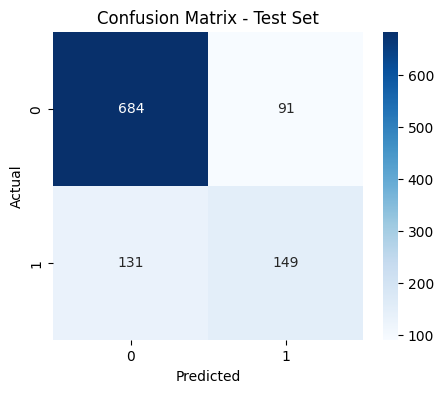


Top-200 Threshold: 0.541905495533328

Metrics at Top-200 Threshold
Precision: 0.63
Recall: 0.45
F1 Score: 0.525


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix
)

# Final Production Model
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train on training data
final_model.fit(X_train_scaled, y_train)

# Predict on test set
y_test_pred = final_model.predict(X_test_scaled)
y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_log_loss = log_loss(y_test, y_test_proba)

# Results Table
test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss"
    ],
    "Test Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc,
        test_log_loss
    ]
})

print(test_results)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Test Set")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Evaluate Top-200 Threshold on Test Set
test_threshold = np.sort(y_test_proba)[-200]

y_test_top200 = (y_test_proba >= test_threshold).astype(int)

top200_precision = precision_score(y_test, y_test_top200)
top200_recall = recall_score(y_test, y_test_top200)
top200_f1 = f1_score(y_test, y_test_top200)

print("\nTop-200 Threshold:", test_threshold)

print("\nMetrics at Top-200 Threshold")
print("Precision:", top200_precision)
print("Recall:", top200_recall)
print("F1 Score:", top200_f1)

In [ ]:
# your code here

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
